# Objectifs généraux

La première partie de ce TP sera consacrée à l’étude de l’utilité des histogrammes et de l’égalisation tandis que la seconde partie sera consacrée au calcul des histogrammes et en fin une dernière partie pour la manipulation du contraste et la luminosité.

## 1. Egalisation des histogrammes

* Charge une image.
* Convertir l'image originale en image en niveaux de gris.
* Égaliser l'histogramme en utilisant la fonction EqualizeHist.
* Afficher et égaliser les images dans une fenêtre.

### 1.1 Déclarer & charger les images source et destination. 

In [1]:
import cv2
fruit = cv2.imread("Fruit.jpg", cv2.IMREAD_COLOR)
orange = cv2.imread("Orange.jpg", cv2.IMREAD_COLOR)

# Tracer l'histogramme de cette image
- cv2.imread(') : Charge l'image en niveaux de gris.

- cv2.calcHist : Calcule l'histogramme de l'image. 
           Le paramètre [0] indique que nous travaillons avec l'unique canal des images en niveaux de gris.
           
- plt.plot(histogram) : Trace l'histogramme avec Matplotlib.

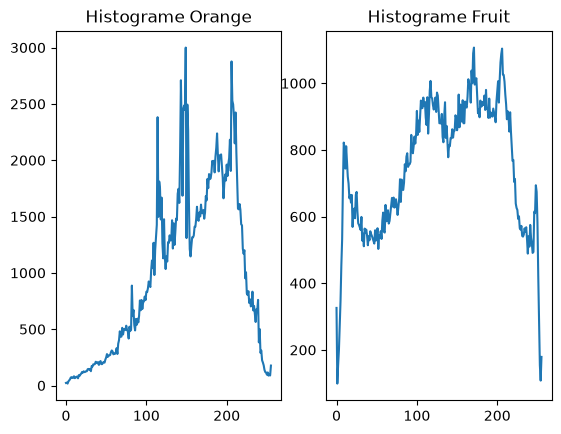

In [2]:
import matplotlib.pyplot as plt
fruit_gray = cv2.imread("Fruit.jpg", cv2.IMREAD_GRAYSCALE)
fruit_hist = cv2.calcHist([fruit_gray], [0], None, [256], [0, 256])
orange_gray = cv2.imread("Orange.jpg", cv2.IMREAD_GRAYSCALE)
orange_hist = cv2.calcHist([orange_gray], [0], None, [256], [0, 256])
fig, axis = plt.subplots(1, 2)
axis[0].set_title("Histograme Orange")
axis[0].plot(orange_hist)
axis[1].set_title("Histograme Fruit")
axis[1].plot(fruit_hist)

# Tracer l'histogramme cumulé 
L'histogramme cumulé représente la somme des fréquences d'intensité des pixels jusqu'à un certain niveau, ce qui permet de mieux comprendre la répartition des intensités sur une image.

In [3]:

import cv2
fruit = cv2.imread("Fruit.jpg", cv2.IMREAD_COLOR)

### 1.2 Convertir l’image en niveau de gris.

In [4]:
fruit_gray = cv2.cvtColor(fruit, cv2.COLOR_BGR2GRAY)

### 1.3 Appliquer l'égalisation d'histogramme avec la fonction equalizeHist.

In [5]:
#fruit_hist = cv2.calcHist([fruit_gray], [0], None, [256], [0, 256])


In [6]:
fruit_equalized = cv2.equalizeHist(fruit_gray)

# tracer l'histogramme de l'image égaliser

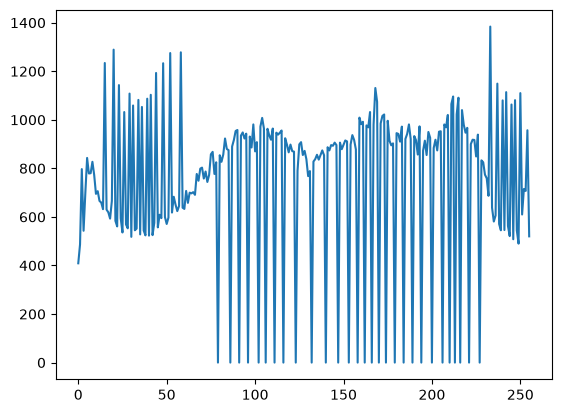

In [7]:
fruit_equalized_hist = cv2.calcHist([fruit_equalized], [0], None, [256], [0, 256])
plt.plot(fruit_equalized_hist)

# Tracer l'histogramme cumulé de l'image égaliser 

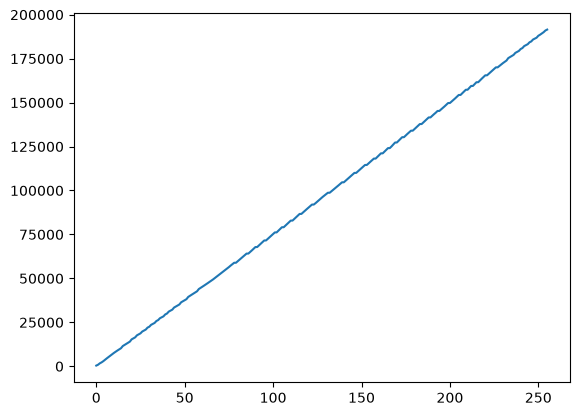

In [8]:
cumulative = fruit_equalized_hist.cumsum()
plt.plot(cumulative)

### Synthèse 1: Interpréter le résultat.

In [9]:
# syhnthèse ?
# Puisque l’image est maintenant égalisée, son histogramme est plus réparti sur toute la plage de niveaux de gris, donc le graphe devient plus plat et plus étendu, avec une pente plus régulière.

## 2. Calcul des histogrammes

* Charge une image
* Diviser l’image en 3 plans (R, G etB) en utilisant la fonction Split
* Calculer l'histogramme de chaque plan en utilisant la fonction calcHist
* Tracer les trois histogrammes dans une fenêtre
* Créer un histogramme normalisé à l’aide de la bibliothèque Matplotlib

### 2.1 Charge une image

In [10]:
fruit = cv2.imread("Fruit.jpg", cv2.IMREAD_COLOR)

### 2.2 Séparer l’image en 3 plans (R, G et B) en utilisant la fonction Split.

In [11]:
b, g, r = cv2.split(fruit)

### 2.3 Application : Calculer l'histogramme de chaque plan en utilisant la fonction calcHist.

* On travaille avec les plans R, G et B donc les valeurs se trouvent dans l’intervalle [0,255].
* Calculer les histogrammes à travers la fonction calcHist.
* Créer un histogramme normalisé à l’aide de la bibliothèque Matplotlib.

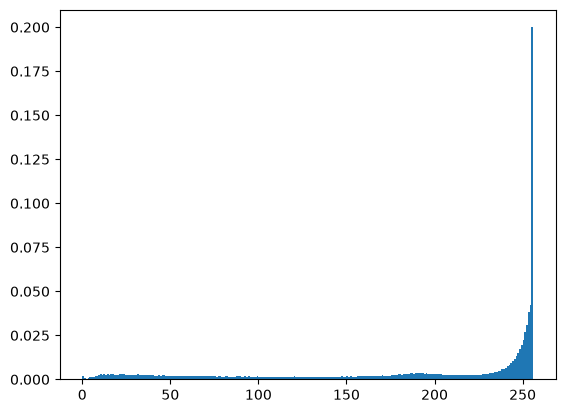

In [12]:
r_hist = cv2.calcHist([r], [0], None, [256], [0, 256])
b_hist = cv2.calcHist([b], [0], None, [256], [0, 256])
g_hist = cv2.calcHist([g], [0], None, [256], [0, 256])
plt.hist(r.ravel(), bins=256, range=(0, 256), density=True)
plt.show()

### Le module Matplotlib

Le module Matplotlib est un module Python complet permettant de créer des tracés statiques et interactifs. Il s’agit d’un package très robuste et simple qui est largement utilisé en science des données à des fins de visualisation. Matplotlib peut être utilisé pour créer un histogramme normalisé. Ce module possède une fonction hist(). qui est utilisé pour créer des histogrammes. 

Voici la définition de la fonction de la méthode hist().

matplotlib.pyplot.hist(x, bins=None, range=None, density=False, weights=None, cumulative=False, bottom=None, histtype='bar', align='mid', orientation='vertical', rwidth=None, log=False, color=None, label=None, stacked=False, *, data=None, **kwargs)

Voici une brève explication des arguments que nous utiliserons pour générer un histogramme normalisé.

x : une liste, un tuple ou un tableau NumPy de valeurs d’entrée.

density : un indicateur booléen pour tracer des valeurs normalisées. Par défaut, c’est False.

color : La couleur des barres de l’histogramme.

label : une étiquette pour les valeurs tracées.

## 3. Manipulation luminosité-contraste

* Charge une image.

* Appliquer la méthode convertScaleAbs pour convertir la couleur de l'image source.

* Afficher les deux images source et destination.

In [13]:
fruit = cv2.imread("Fruit.jpg", cv2.IMREAD_COLOR)
fruit_rgb = cv2.cvtColor(fruit, cv2.COLOR_BGR2RGB)

In [45]:
fruit_converted = cv2.convertScaleAbs(fruit_rgb, None, 1.0, -50.0)

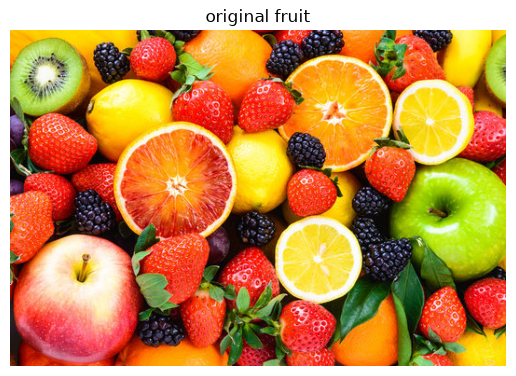

In [15]:
plt.title("original fruit")
plt.imshow(fruit_rgb)
plt.axis("off")
plt.show()

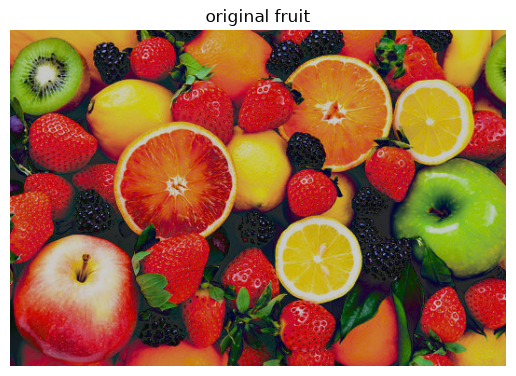

In [46]:
plt.title("original fruit")
plt.imshow(fruit_converted)
plt.axis("off")
plt.show()

### Application : 
Modifier la valeur de « beta » plusieurs fois et comparer entres les histogrammes de l’image source (état initial et après  modification du coefficient  « beta »).


## L'étirement d'histogramme
L'étirement d'histogramme est une méthode d'amélioration d'image qui étend la plage de valeurs d'intensité des pixels dans une image pour augmenter son contraste. Cela est utile lorsque l'image a une faible variation de luminosité.

In [55]:


fruit_converted1 = cv2.convertScaleAbs(fruit_rgb, None, 1.0, 50.5)
fruit_converted2 = cv2.convertScaleAbs(fruit_rgb, None, 1.0, 100.5)
fruit_converted3 = cv2.convertScaleAbs(fruit_rgb, None, 1.0, -50.5)

fruit_rgb_r_hist = cv2.calcHist([fruit_rgb], [0], None, [256], [0, 256])
fruit_rgb_g_hist = cv2.calcHist([fruit_rgb], [1], None, [256], [0, 256])
fruit_rgb_b_hist = cv2.calcHist([fruit_rgb], [2], None, [256], [0, 256])

fruit_converted1_r_hist = cv2.calcHist([fruit_converted1], [0], None, [256], [0, 256])
fruit_converted1_g_hist = cv2.calcHist([fruit_converted1], [1], None, [256], [0, 256])
fruit_converted1_b_hist = cv2.calcHist([fruit_converted1], [2], None, [256], [0, 256])

fruit_converted2_r_hist = cv2.calcHist([fruit_converted2], [0], None, [256], [0, 256])
fruit_converted2_g_hist = cv2.calcHist([fruit_converted2], [1], None, [256], [0, 256])
fruit_converted2_b_hist = cv2.calcHist([fruit_converted2], [2], None, [256], [0, 256])

fruit_converted3_r_hist = cv2.calcHist([fruit_converted3], [0], None, [256], [0, 256])
fruit_converted3_g_hist = cv2.calcHist([fruit_converted3], [1], None, [256], [0, 256])
fruit_converted3_b_hist = cv2.calcHist([fruit_converted3], [2], None, [256], [0, 256])

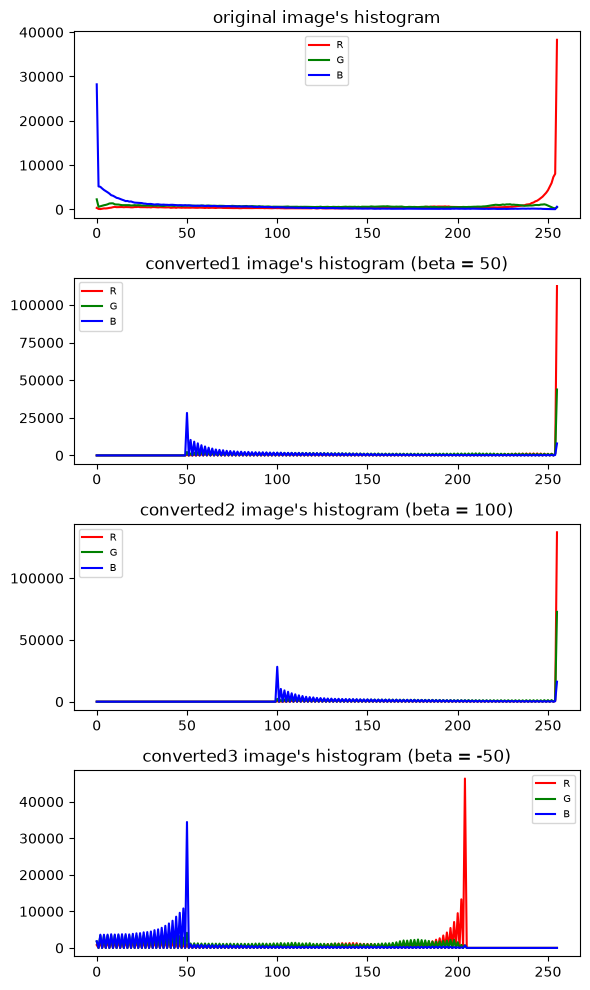

In [58]:
fig, axis = plt.subplots(4, 1, figsize=(6, 10))

axis[0].set_title("original image's histogram")
axis[0].plot(fruit_rgb_r_hist, color="r", label="R")
axis[0].plot(fruit_rgb_g_hist, color="g", label="G")
axis[0].plot(fruit_rgb_b_hist, color="b", label="B")
axis[0].legend(fontsize=7)

axis[1].set_title("converted1 image's histogram (beta = 50)")
axis[1].plot(fruit_converted1_r_hist, color="r", label="R")
axis[1].plot(fruit_converted1_g_hist, color="g", label="G")
axis[1].plot(fruit_converted1_b_hist, color="b", label="B")
axis[1].legend(fontsize=7)

axis[2].set_title("converted2 image's histogram (beta = 100)")
axis[2].plot(fruit_converted2_r_hist, color="r", label="R")
axis[2].plot(fruit_converted2_g_hist, color="g", label="G")
axis[2].plot(fruit_converted2_b_hist, color="b", label="B")
axis[2].legend(fontsize=7)

axis[3].set_title("converted3 image's histogram (beta = -50)")
axis[3].plot(fruit_converted3_r_hist, color="r", label="R")
axis[3].plot(fruit_converted3_g_hist, color="g", label="G")
axis[3].plot(fruit_converted3_b_hist, color="b", label="B")
axis[3].legend(fontsize=7)

fig.tight_layout()
plt.show()
#plt.title("comparing histograms based on beta value change")